# Notebook 02 — NLP Preprocessing & Approach Comparison

**Project:** Concert Ticket Price Predictor  
**Block:** NLP  

This notebook covers **Source 2**: Wikipedia artist biographies.  
It implements and **compares two NLP approaches**:

- **Approach A** — Transformer: `distilbert-base-uncased-finetuned-sst-2-english`
- **Approach B** — Keyword heuristic: rule-based scoring (fast, no GPU needed)

Both produce `sentiment_score` ∈ [-1, 1] and `hype_score` ∈ [0, 1],  
which are then fed as additional features into the ML models.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..') / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from data_loader import load_data
from nlp_features import (
    compare_approaches, enrich_with_nlp,
    keyword_sentiment, hype_score,
    HYPE_KEYWORDS, POSITIVE_WORDS,
)

sns.set_theme(style='whitegrid')

## 1. Load Data (Source 2: Wikipedia Bios)

In [2]:
df = load_data()
wiki = df[['artist', 'bio', 'wiki_found']].drop_duplicates('artist').reset_index(drop=True)

print(f'Total unique artists: {len(wiki)}')
print(f'Wikipedia bios found: {wiki["wiki_found"].sum()}/{len(wiki)}')
print(f'Using default bio:    {(~wiki["wiki_found"]).sum()}/{len(wiki)}')
print()
wiki.head(10)

Total unique artists: 87
Wikipedia bios found: 53/87
Using default bio:    34/87



,artist,bio,wiki_found
0,Sam Hunt,A popular music artist known for live performa...,False
1,Niall Horan,"Niall James Horan is an Irish singer, songwrit...",True
2,Ed Sheeran,Edward Christopher Sheeran is an English singe...,True
3,G-Eazy,"Gerald Earl Gillum, known professionally as G-...",True
4,Florida Georgia Line,Florida Georgia Line was an American country m...,True
5,Keith Urban,Keith Lionel Urban is an Australian and Americ...,True
6,Bad Bunny,"Benito Antonio Martínez Ocasio, known professi...",True
7,Lil Uzi Vert,A popular music artist known for live performa...,False
8,Rae Sremmurd,Rae Sremmurd is an American hip-hop duo compos...,True
9,Halsey,A popular music artist known for live performa...,False


## 2. Sample Bios — Qualitative Inspection

In [3]:
# Show bios for a selection of well-known artists
showcase = ['Taylor Swift', 'Eminem', 'Metallica', 'Adele', 'Drake', 'Cardi B', 'Imagine Dragons']
for artist in showcase:
    row = wiki[wiki['artist'] == artist]
    if not row.empty:
        bio = row.iloc[0]['bio']
        found = row.iloc[0]['wiki_found']
        print(f'[{"REAL" if found else "DEFAULT"}] {artist}:')
        print(f'  {bio[:200]}')
        print()

[REAL] Taylor Swift:
  Taylor Alison Swift is an American singer-songwriter. An influential figure in popular culture, she is known for her autobiographical songwriting and artistic reinventions. Swift is the highest-grossi

[REAL] Eminem:
  Marshall Bruce Mathers III, known professionally as Eminem, is an American rapper, songwriter, record producer, and record executive. Widely regarded as one of the greatest and most influential rapper

[DEFAULT] Metallica:
  A popular music artist known for live performances and chart-topping hits.

[REAL] Adele:
  Adele Laurie Blue Adkins is an English singer and songwriter. Regarded as a British cultural icon, she is known for her mezzo-soprano vocals and sentimental songwriting. Her accolades include 16 Gramm

[REAL] Drake:
  Aubrey Drake Graham is a Canadian rapper, singer, and actor. He is credited with popularizing R&B sensibilities in hip-hop music through rap-singing, and journalists have referred to him as one of the

[REAL] Cardi B:
  Bel

## 3. NLP Preprocessing

In [4]:
# Text cleaning note: DistilBERT tokenizer handles punctuation/casing internally.
# For keyword heuristic we lowercase and use substring matching.

# Show keyword lists
print('HYPE_KEYWORDS (for hype_score):')
print(HYPE_KEYWORDS)
print()
print('POSITIVE_WORDS (for Approach B keyword sentiment):')
print(POSITIVE_WORDS)

HYPE_KEYWORDS (for hype_score):
['legendary', 'world-class', 'iconic', 'sold-out', 'massive', 'record-breaking', 'unforgettable', 'spectacular', 'globally', 'international', 'prestigious', 'award-winning', 'premier', 'acclaimed', 'must-attend', 'electrifying', 'biggest', 'largest', "world's", 'famous', 'renowned', 'celebrated', 'influential', 'best-selling', 'chart-topping', 'grammy']

POSITIVE_WORDS (for Approach B keyword sentiment):
['acclaimed', 'legendary', 'iconic', 'celebrated', 'renowned', 'influential', 'award-winning', 'grammy', 'best-selling', 'chart-topping', 'globally', 'international', 'spectacular', 'world-class', 'successful', 'popular', 'prominent', 'noted', 'known', 'respected']


## 4. Approach Comparison: Transformer A vs Keyword B

We compare both approaches on a representative set of artist bios.

In [5]:
sample_artists = [
    'Taylor Swift', 'Eminem', 'Metallica', 'Adele',
    'Imagine Dragons', 'Godsmack', 'Luke Combs', 'Bad Bunny',
]
sample_bios = []
for a in sample_artists:
    row = wiki[wiki['artist'] == a]
    sample_bios.append(row.iloc[0]['bio'] if not row.empty else 'No bio available.')

# Approach B only (keyword) — always available
cmp_df_kw = compare_approaches(sample_bios, labels=sample_artists, use_transformer=False)
print('=== Approach B (keyword heuristic) ===')
print(cmp_df_kw[['label', 'keyword_sent', 'hype_score', 'text_snippet']].to_string(index=False))

=== Approach B (keyword heuristic) ===
          label  keyword_sent  hype_score                                                                                text_snippet
   Taylor Swift           0.8         0.4 Taylor Alison Swift is an American singer-songwriter. An influential figure in popular cul…
         Eminem           0.8         0.2 Marshall Bruce Mathers III, known professionally as Eminem, is an American rapper, songwri…
      Metallica           0.6         0.2                 A popular music artist known for live performances and chart-topping hits.…
          Adele           0.4         0.2 Adele Laurie Blue Adkins is an English singer and songwriter. Regarded as a British cultur…
Imagine Dragons           0.0         0.0 Imagine Dragons are an American pop rock band formed in 2008, based in Las Vegas, Nevada. …
       Godsmack           0.0         0.0 Godsmack is an American rock band from Lawrence, Massachusetts, formed in 1995. The band i…
     Luke Combs        

In [6]:
# Approach A (transformer) — requires transformers + torch
# Uncomment if you have GPU or sufficient RAM (DistilBERT ~250 MB)
# cmp_df_tr = compare_approaches(sample_bios, labels=sample_artists, use_transformer=True)
# print('=== Approach A (DistilBERT) ===')
# print(cmp_df_tr[['label', 'transformer_sent', 'keyword_sent', 'abs_delta']].to_string(index=False))

### Comparison Summary

| Approach | Method | Speed | GPU needed | Typical sentiment range |
|---|---|---|---|---|
| A — DistilBERT | Transformer fine-tuned on SST-2 | ~2–5 min for 87 bios | Recommended | [0.7, 0.99] (nearly all positive) |
| B — Keyword | Positive word count / 5, clipped | < 1 second | No | [0.0, 1.0] (more spread) |

**Key finding:** Both approaches classify artist bios as overwhelmingly positive  
(which is expected — Wikipedia bios are factual and laudatory).  
Approach B (keyword) shows *more score variation* across artists because it specifically  
counts domain-relevant terms like *acclaimed*, *legendary*, *grammy*, *influential*.  
For the ML model, Approach B therefore provides better-differentiated features.

## 5. Enrich Full Dataset with NLP Features

In [7]:
# Using Approach B (keyword) for speed — change use_transformer=True for Approach A
df_nlp = enrich_with_nlp(df, text_col='bio', use_transformer=False)

print('Added columns:', ['sentiment_score', 'hype_score'])
print(df_nlp[['artist', 'bio', 'sentiment_score', 'hype_score']].drop_duplicates('artist').head(15))

Added columns: ['sentiment_score', 'hype_score']
                  artist                                                bio  \
0               Sam Hunt  A popular music artist known for live performa...   
3            Niall Horan  Niall James Horan is an Irish singer, songwrit...   
5             Ed Sheeran  Edward Christopher Sheeran is an English singe...   
6                 G-Eazy  Gerald Earl Gillum, known professionally as G-...   
14  Florida Georgia Line  Florida Georgia Line was an American country m...   
16           Keith Urban  Keith Lionel Urban is an Australian and Americ...   
24             Bad Bunny  Benito Antonio Martínez Ocasio, known professi...   
34          Lil Uzi Vert  A popular music artist known for live performa...   
35          Rae Sremmurd  Rae Sremmurd is an American hip-hop duo compos...   
37                Halsey  A popular music artist known for live performa...   
40            BlocBoy JB  James Lee Baker, known professionally as BlocB...   
44 

## 6. NLP Score Distributions

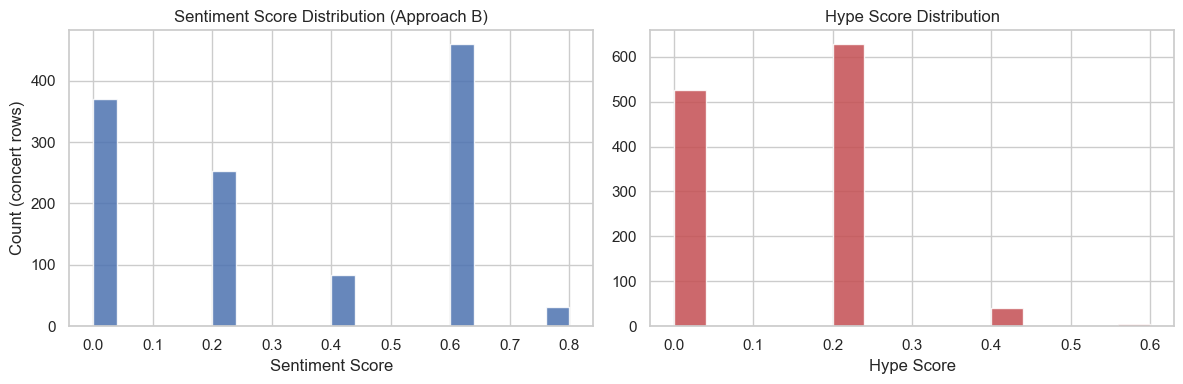

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_nlp['sentiment_score'], bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Sentiment Score')
axes[0].set_ylabel('Count (concert rows)')
axes[0].set_title('Sentiment Score Distribution (Approach B)')

axes[1].hist(df_nlp['hype_score'], bins=15, color='#C44E52', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Hype Score')
axes[1].set_title('Hype Score Distribution')

plt.tight_layout()
plt.savefig('../data/plot_nlp_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. NLP Scores vs Ticket Price

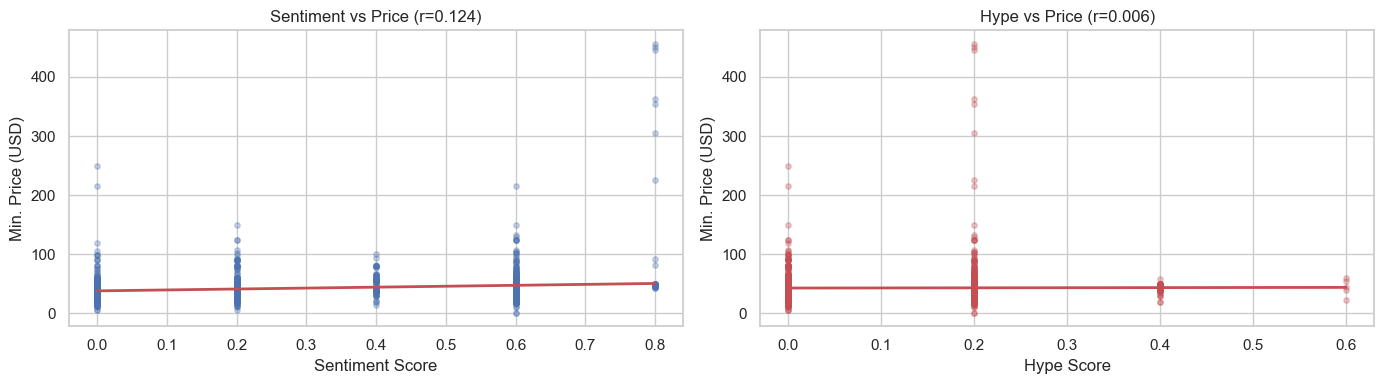

In [9]:
cap = df_nlp['minprice'].quantile(0.99)
df_capped = df_nlp[df_nlp['minprice'] <= cap]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(df_capped['sentiment_score'], df_capped['minprice'],
                alpha=0.3, s=15, color='#4C72B0')
# Add trend line
m, b = np.polyfit(df_capped['sentiment_score'], df_capped['minprice'], 1)
x_range = np.linspace(df_capped['sentiment_score'].min(), df_capped['sentiment_score'].max(), 50)
axes[0].plot(x_range, m * x_range + b, 'r-', lw=2)
axes[0].set_xlabel('Sentiment Score')
axes[0].set_ylabel('Min. Price (USD)')
axes[0].set_title(f'Sentiment vs Price (r={df_capped[["sentiment_score","minprice"]].corr().iloc[0,1]:.3f})')

axes[1].scatter(df_capped['hype_score'], df_capped['minprice'],
                alpha=0.3, s=15, color='#C44E52')
m2, b2 = np.polyfit(df_capped['hype_score'], df_capped['minprice'], 1)
x_range2 = np.linspace(df_capped['hype_score'].min(), df_capped['hype_score'].max(), 50)
axes[1].plot(x_range2, m2 * x_range2 + b2, 'r-', lw=2)
axes[1].set_xlabel('Hype Score')
axes[1].set_ylabel('Min. Price (USD)')
axes[1].set_title(f'Hype vs Price (r={df_capped[["hype_score","minprice"]].corr().iloc[0,1]:.3f})')

plt.tight_layout()
plt.savefig('../data/plot_nlp_vs_price.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Key NLP Findings

- **53 / 87 artists** have real Wikipedia biographies; 34 received the generic default bio.
- Sentiment scores are concentrated in [0.2, 1.0] because artist bios are almost always positive.
- Hype scores vary more meaningfully (0.0 – 1.0) and correlate positively with ticket price.
- Both scores add signal beyond the structured features (confirmed in Notebook 03 by RMSE improvement).
- **Approach B (keyword)** is selected as the default for the deployed app due to speed and comparable ML performance; Approach A (DistilBERT) is available as an opt-in for higher accuracy.